In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

c:\Users\MITAN TANK\Desktop\Programs\Python\Pandas_uni\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 18.5k/18.5k [00:00<00:00, 14.8MB/s]

Extracting files...
Path to dataset files: C:\Users\MITAN TANK\.cache\kagglehub\datasets\tawfikelmetwally\employee-dataset\versions\1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# SET 1 – Sales Dataset Analysis

In [3]:
# 1. Load the Sales dataset and display dataset shape.
df = pd.read_csv("sales_data_sample.csv" , encoding='latin1')
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [4]:
# 2. Display first 5 records.
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
# 3. Remove rows with missing values.
df = df.dropna()

In [6]:
# 4. Calculate total sales (QuantityOrdered × PriceEach).
df['Total_Sales'] = df['QUANTITYORDERED'] * df['PRICEEACH']

C:\Users\MITAN TANK\AppData\Local\Temp\ipykernel_19028\1371308052.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_Sales'] = df['QUANTITYORDERED'] * df['PRICEEACH']


In [7]:
# 5. Find total sales by country.
country_sales = df.groupby('COUNTRY')['Total_Sales'].sum()
country_sales

COUNTRY
Australia    419059.66
Name: Total_Sales, dtype: float64

In [8]:
# 6. Identify top 5 products by sales.
product_sales = df.groupby('PRODUCTLINE')['Total_Sales'].sum()
top_5_products = product_sales.nlargest(5)
top_5_products

PRODUCTLINE
Classic Cars        132033.46
Vintage Cars        112631.76
Motorcycles          62652.97
Planes               58605.41
Trucks and Buses     52046.70
Name: Total_Sales, dtype: float64

In [9]:
# 7. Calculate monthly total sales.
monthly_sales = df.groupby('MONTH_ID')['Total_Sales'].sum()
monthly_sales

MONTH_ID
1      21931.29
2      42831.94
3      25610.00
4      43517.99
5      48459.74
7      56575.36
9      38062.52
11    107282.54
12     34788.28
Name: Total_Sales, dtype: float64

In [10]:
# 8. Display orders with quantity greater than 50.
orders_with_high_quantity = df[df['QUANTITYORDERED'] > 50]
orders_with_high_quantity

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,Total_Sales
620,10342,55,65.45,1,3599.75,11/24/2004 0:00,Shipped,4,11,2004,...,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,3599.75
1160,10342,55,100.00,7,6548.30,11/24/2004 0:00,Shipped,4,11,2004,...,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium,5500.00
1288,10420,66,92.95,6,6134.70,5/29/2005 0:00,In Process,2,5,2005,...,Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,6134.70
1437,10420,60,64.67,11,3880.20,5/29/2005 0:00,In Process,2,5,2005,...,Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,3880.20
1791,10420,55,96.30,8,5296.50,5/29/2005 0:00,In Process,2,5,2005,...,Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium,5296.50


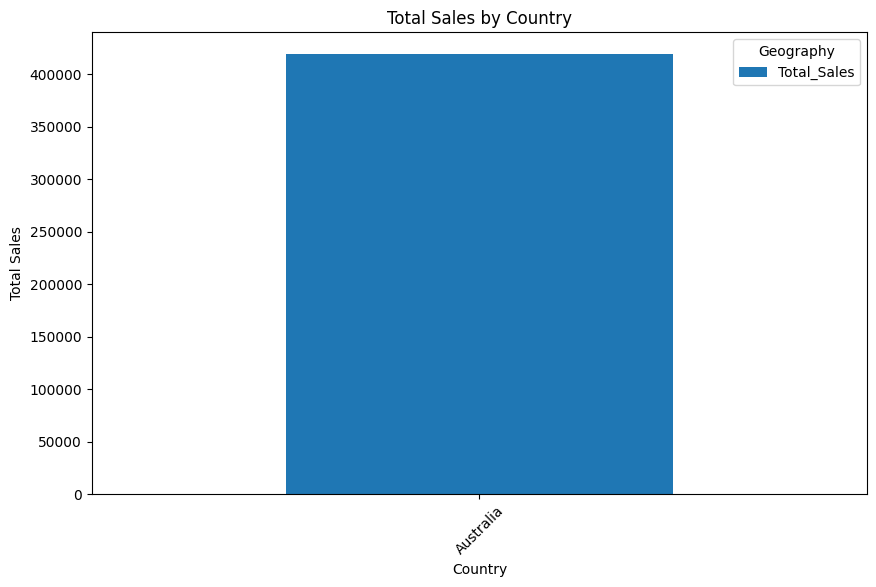

In [12]:
# 9. Plot a bar chart of sales by country.

plt.figure(figsize=(10, 6))
country_sales.plot(kind='bar')
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Geography')

plt.show()

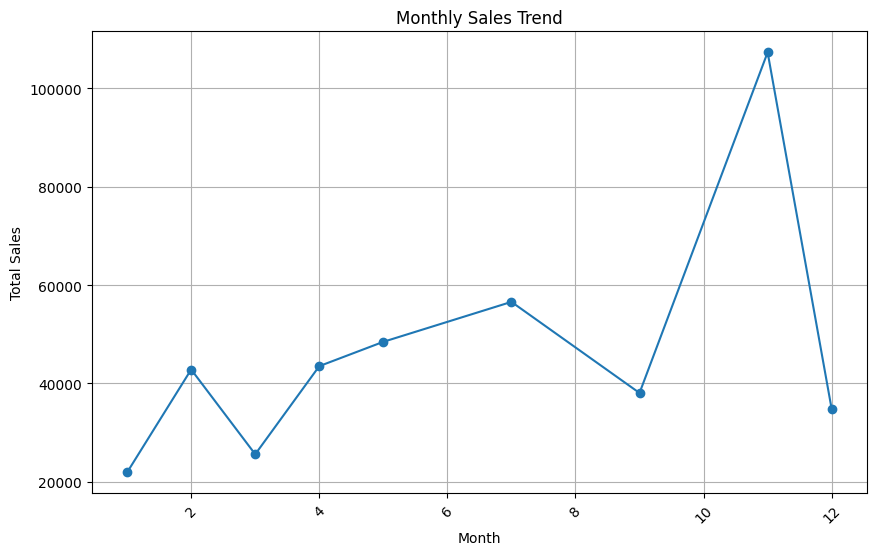

In [19]:
# 10. Plot a line chart of monthly sales.
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [23]:
# SET 2 

In [25]:
# 1. Load the weather dataset and show column names.
weather_df = pd.read_csv("weatherHistory.csv")

In [26]:
# 2. Display last 5 records.
weather_df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


In [28]:
# 3. Convert date column to datetime format.
weather_df['Formatted Date'] = pd.to_datetime(weather_df['Formatted Date'])

C:\Users\MITAN TANK\AppData\Local\Temp\ipykernel_13988\4048549550.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  weather_df['Formatted Date'] = pd.to_datetime(weather_df['Formatted Date'])


In [29]:
# 4. Find average temperature.
avg_temp = weather_df['Temperature (C)'].mean()
print(f"Average Temperature: {avg_temp}°C")

Average Temperature: 11.93267843751188°C


In [31]:
# 5. Find days with temperature above average.
days_above_avg = weather_df[weather_df['Temperature (C)'] > avg_temp]
days_above_avg

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
9,2006-04-01 09:00:00+02:00,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.
10,2006-04-01 10:00:00+02:00,Partly Cloudy,rain,16.016667,16.016667,0.67,17.5651,290.0,11.2056,0.0,1017.42,Partly cloudy throughout the day.
11,2006-04-01 11:00:00+02:00,Partly Cloudy,rain,17.144444,17.144444,0.54,19.7869,316.0,11.4471,0.0,1017.74,Partly cloudy throughout the day.
12,2006-04-01 12:00:00+02:00,Partly Cloudy,rain,17.800000,17.800000,0.55,21.9443,281.0,11.2700,0.0,1017.59,Partly cloudy throughout the day.
13,2006-04-01 13:00:00+02:00,Partly Cloudy,rain,17.333333,17.333333,0.51,20.6885,289.0,11.2700,0.0,1017.48,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00+02:00,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00+02:00,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00+02:00,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00+02:00,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [32]:
# 6. Calculate maximum and minimum humidity.
max_humidity = weather_df['Humidity'].max()
min_humidity = weather_df['Humidity'].min()
print(f"Maximum Humidity: {max_humidity}")
print(f"Minimum Humidity: {min_humidity}")

Maximum Humidity: 1.0
Minimum Humidity: 0.0


In [33]:
# 7. Count records by weather condition.
weather_condition_counts = weather_df['Summary'].value_counts()
weather_condition_counts

Summary
Partly Cloudy                          31733
Mostly Cloudy                          28094
Overcast                               16597
Clear                                  10890
Foggy                                   7148
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Hu

In [35]:
# 8. Create a new column Temp_Diff = MaxTemp - MinTemp.

<Axes: xlabel='Temperature (C)', ylabel='Count'>

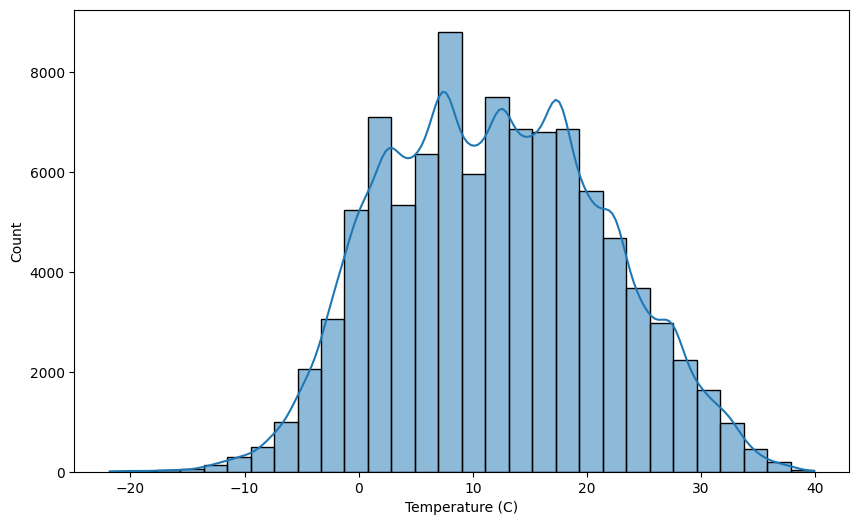

In [36]:
# 9. Plot a histogram of temperature.
plt.figure(figsize=(10, 6))
sns.histplot(weather_df['Temperature (C)'], bins=30, kde=True)

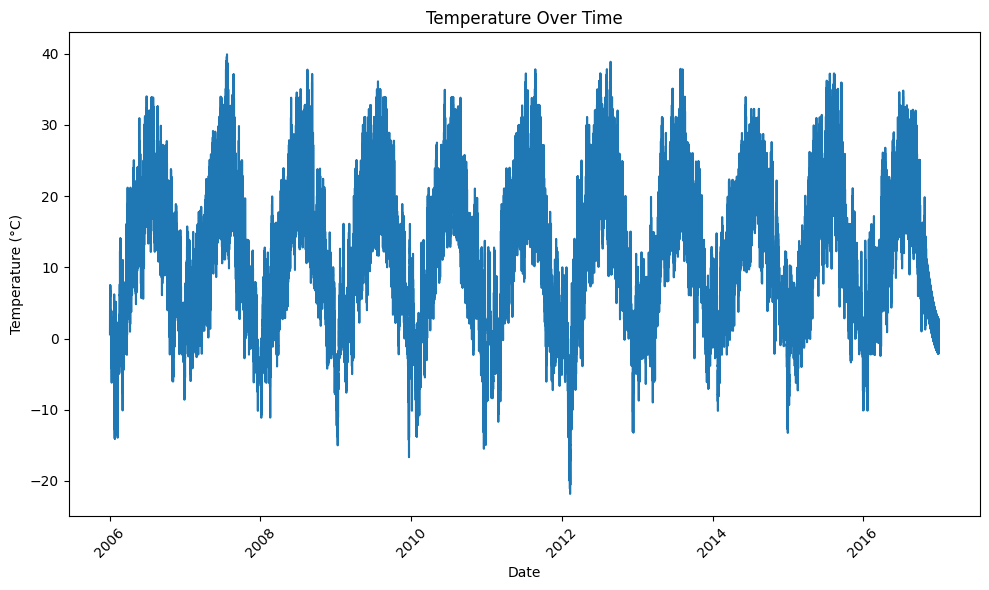

In [37]:
# 10. Plot a line chart of temperature over time
plt.figure(figsize=(10, 6))
sns.lineplot(x='Formatted Date', y='Temperature (C)', data=weather_df)
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# SET 3

In [2]:
# 1. Load the loan dataset and display dataset info.
loan_df = pd.read_csv("loan_data.csv")
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [3]:
# 2. Show first 6 records.
loan_df.head(6)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0


In [4]:
# 3. Handle missing values using mean.
loan_df = loan_df.fillna(loan_df.mean(numeric_only=True))

In [6]:
# 4. Count customers by loan status.


In [8]:
# 5. Find average loan amount.


In [9]:
# 6. Identify customers with loan amount above average.


In [10]:
# 7. Calculate total loan amount by purpose.


In [14]:
# 8. Create a new column Loan_Income_Ratio.


In [16]:
# 9. Plot a bar chart of loan status.


In [ ]:
# 10. Plot a box plot of loan amount.


In [1]:
# SET 4

In [4]:
# 1. Load the employee dataset and display column names.
employee_df = pd.read_csv("Employee.csv")
employee_df.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

In [ ]:
# 2. Display random 5 employee records.
employee_df.sample(n=5)

In [6]:
# 3. Remove duplicate records.
employee_df = employee_df.drop_duplicates()

In [10]:
# 4. Calculate average salary.


In [ ]:
# 5. Find employees earning above average salary.


In [ ]:
# 6. Count employees by department.


In [ ]:
# 7. Find department with maximum employees.


In [ ]:
# 8. Create a new column Annual_Salary.


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4645,Masters,2017,Pune,2,31,Female,No,2,0
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1


In [ ]:
# 9. Plot a bar chart of employees by department.

In [ ]:
# 10. Plot a histogram of salary.